<a href="https://colab.research.google.com/github/Ramankur07/AIML-LAB/blob/main/code3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Road Network Adjacency List:
  CityA: ['CityB', 'CityC']
  CityB: ['CityA', 'CityD']
  CityC: ['CityA', 'CityE']
  CityD: ['CityB']
  CityE: ['CityC']
  CityF: ['CityG']
  CityG: ['CityF']
  CityH: []


--- Route Checking ---
Route exists from CityA to CityD.
No route from CityA to CityF.


--- Connected Components ---
Component 1: CityA, CityB, CityC, CityD, CityE
Component 2: CityF, CityG
Component 3: CityH




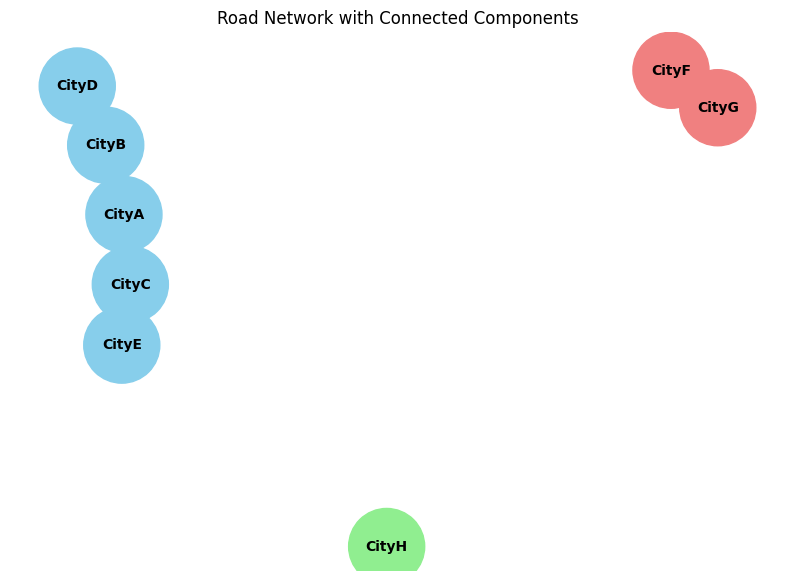

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the road network (adjacency list)
road_network = {
    'CityA': ['CityB', 'CityC'],
    'CityB': ['CityA', 'CityD'],
    'CityC': ['CityA', 'CityE'],
    'CityD': ['CityB'],
    'CityE': ['CityC'],
    'CityF': ['CityG'],
    'CityG': ['CityF'],
    'CityH': []
}

print("Road Network Adjacency List:")
for city, neighbors in road_network.items():
    print(f"  {city}: {neighbors}")
print("\n")

# 1. Function to check if a route exists between two cities using DFS
def dfs_check_route(graph, start_city, end_city):
    visited = set()
    stack = [start_city]

    while stack:
        current_city = stack.pop()
        if current_city == end_city:
            return True # Route found

        if current_city not in visited:
            visited.add(current_city)
            # Add neighbors to stack (order doesn't strictly matter for existence check)
            for neighbor in graph.get(current_city, []):
                if neighbor not in visited:
                    stack.append(neighbor)
    return False # No route found

# Test route checking
print("--- Route Checking ---")
start_1, end_1 = 'CityA', 'CityD'
if dfs_check_route(road_network, start_1, end_1):
    print(f"Route exists from {start_1} to {end_1}.")
else:
    print(f"No route from {start_1} to {end_1}.")

start_2, end_2 = 'CityA', 'CityF'
if dfs_check_route(road_network, start_2, end_2):
    print(f"Route exists from {start_2} to {end_2}.")
else:
    print(f"No route from {start_2} to {end_2}.")

print("\n")

# 2. Function to find all connected components using DFS
def find_connected_components(graph):
    visited = set()
    connected_components = []

    def dfs_explore(city, current_component):
        visited.add(city)
        current_component.append(city)
        for neighbor in graph.get(city, []):
            if neighbor not in visited:
                dfs_explore(neighbor, current_component)

    for city in graph:
        if city not in visited:
            component = []
            dfs_explore(city, component)
            connected_components.append(component)

    return connected_components

# Find and print connected components
print("--- Connected Components ---")
components = find_connected_components(road_network)
for i, component in enumerate(components):
    print(f"Component {i+1}: {', '.join(sorted(component))}")
print("\n")

# Optional: Visualize the graph and its components
def draw_graph_with_components(graph_dict, components):
    G = nx.Graph()

    # Add nodes and edges
    for city, neighbors in graph_dict.items():
        G.add_node(city)
        for neighbor in neighbors:
            G.add_edge(city, neighbor)

    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42) # For reproducible layout

    # Assign a unique color to each component
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple', 'lightpink']
    node_colors = []
    for node in G.nodes():
        for i, component in enumerate(components):
            if node in component:
                node_colors.append(colors[i % len(colors)])
                break

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000)
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    plt.title("Road Network with Connected Components")
    plt.axis('off')
    plt.show()

draw_graph_with_components(road_network, components)
